In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import pylab as py

## 2.a.  
We say $Z_t$ is WN iif $\mathbb{E}(Z_t)=0$ and $\mathbb{V}(Z_t)=1$. Therefore, we set $Z_t = \frac{D_t - \mathbb{E}(D_t)}{\operatorname{sd}(D_t)}$ with  
$\mathbb{E}(D_t) = 3.5$  
$\operatorname{sd}(D_t) = 1.7$

In [3]:
def WNdice(N):
    sd = np.sqrt( 2*(2.5**2 + 1.5**2 + 0.5**2)/6 )
    E = 3.5
    D_t = np.random.randint(1,7, size = N)
    Z_t = (D_t - E)/sd
    return Z_t

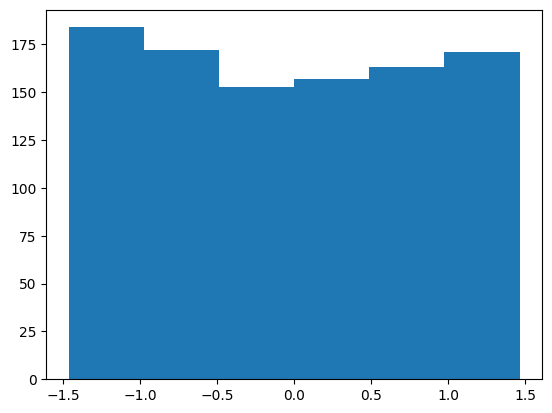

In [4]:
plt.hist(WNdice(1000), bins = 6)
plt.show()

## 2.b.

In [5]:
def GARCH11path(N, burn_in, a0, a1, b, WN='WNdice'):
    X = np.zeros(N+burn_in)
    sigma = np.zeros(N+burn_in)
    X[0] = 0
    sigma[0] = 1

    if WN == 'WNdice':
        Z = WNdice(N+burn_in)
    if WN == 'WNnormal':
        Z = np.random.normal(size=N+burn_in)
    if WN == 'WNt':
        Z = np.random.standard_t(3,size=N+burn_in)

    for i in range(1, N+burn_in):
        sigma[i] = np.sqrt(a0 + a1*X[i-1]**2 + b*sigma[i-1]**2)
        X[i] = sigma[i]*Z[i]
    
    return X[burn_in:], sigma[burn_in:]

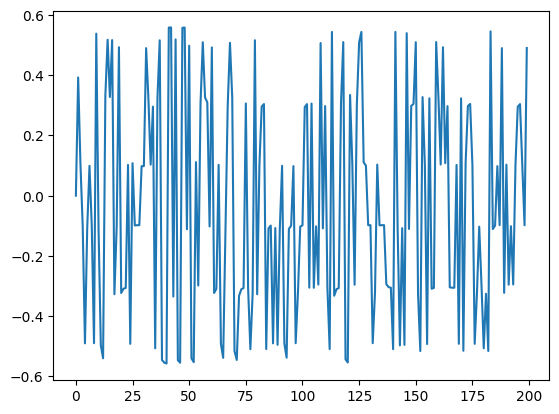

In [6]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0.1, a1=0.1, b=0.1)[0])

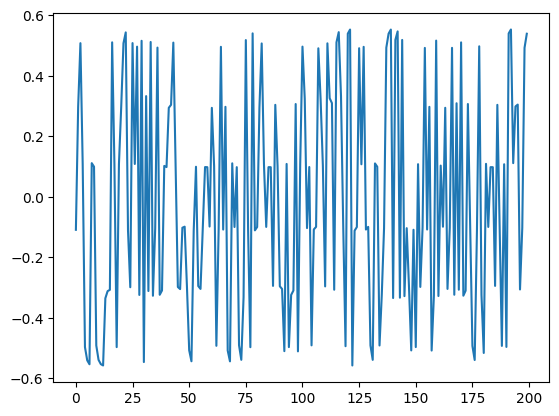

In [7]:
plt.plot(GARCH11path(N=200, burn_in=1000, a0=0.1, a1=0.1, b=0.1)[0])

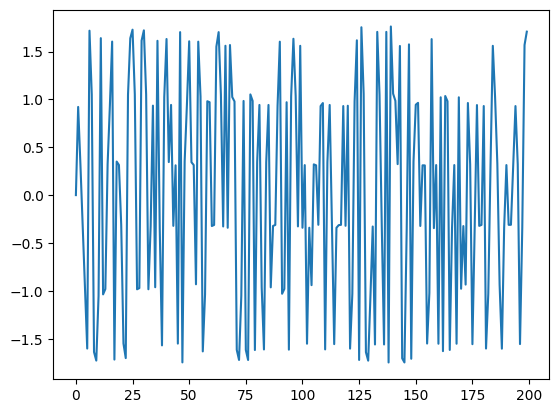

In [8]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=1, a1=0.1, b=0.1)[0])

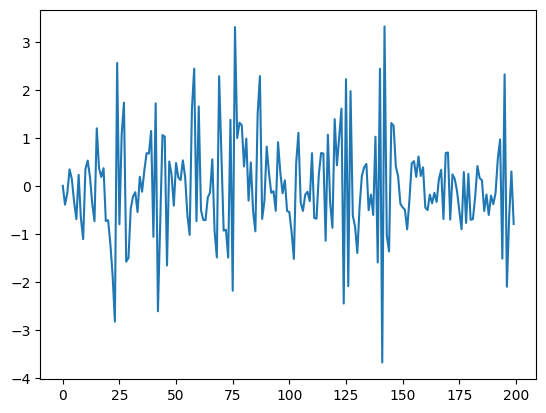

In [9]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0.1, a1=1, b=0.1)[0])

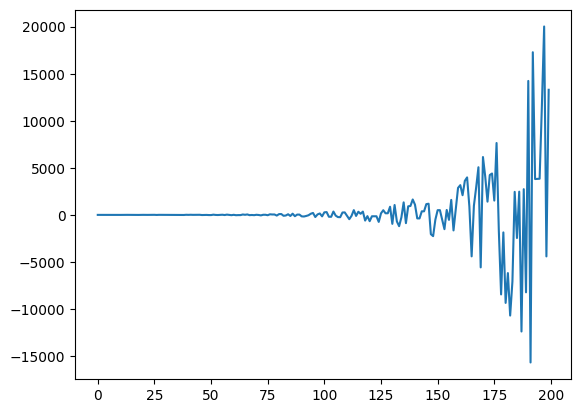

In [10]:
plt.plot(GARCH11path(N=200, burn_in=0, a0= 0.1, a1=0.1, b=1)[0])

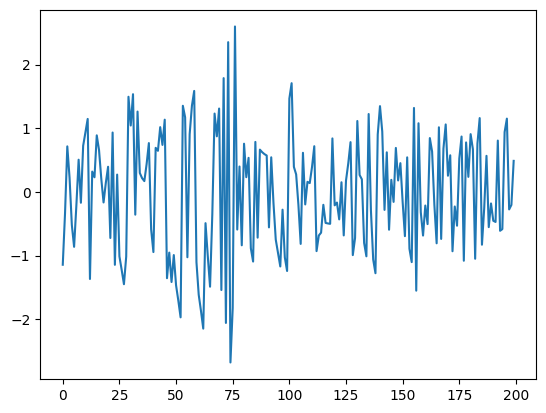

In [11]:
plt.plot(GARCH11path(N=200, burn_in=1000, a0=0.1, a1=0.4, b=0.4)[0])

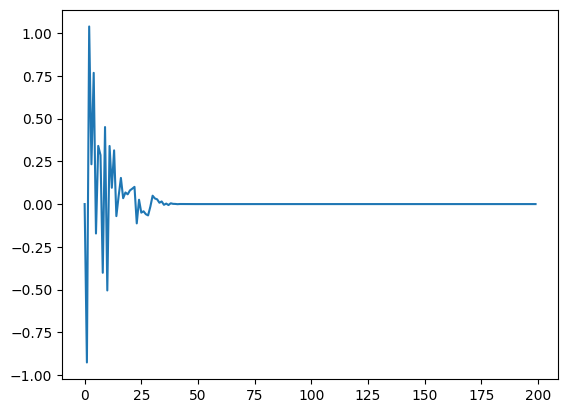

In [12]:
plt.plot(GARCH11path(N=200, burn_in=0, a0=0, a1=0.4, b=0.4)[0])

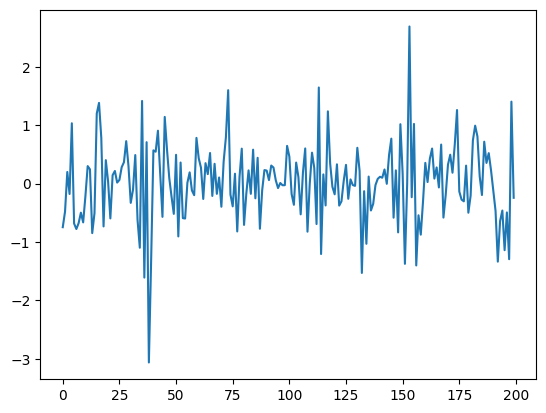

In [13]:
plt.plot(GARCH11path(N=200, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNnormal')[0])

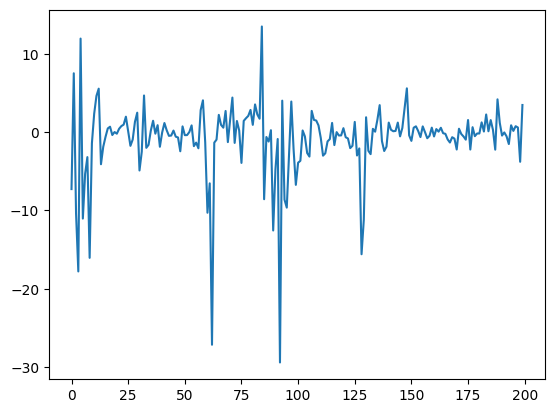

In [14]:
plt.plot(GARCH11path(N=200, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNt')[0]) #for df = 1 or 2, the process is not stationary.

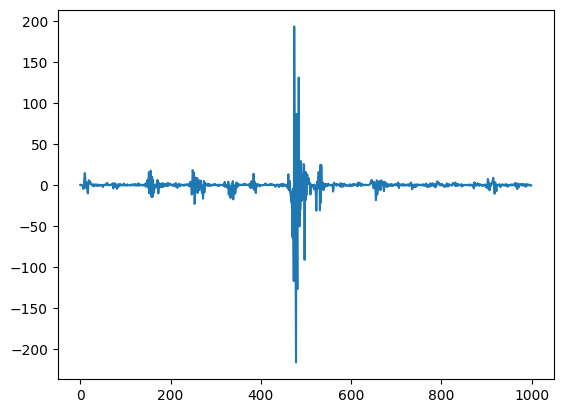

In [15]:
plt.plot(GARCH11path(N=1000, burn_in=10000, a0=0.1, a1=0.4, b=0.4, WN='WNt')[0]) #wildcard, sometimes very reasonably looking plot, sometimes reaches 2000 in a volatility cluster.

## 5

In [70]:
DAX = pd.read_csv('Data/GDAXI.csv')
SP500 = pd.read_csv('Data/GSPC.csv')

DAX.columns = ['Date', 'Open', 'High', 'Low', 'Close']
SP500.columns = ['Date', 'Open', 'High', 'Low', 'Close']

DAX['Date'] = pd.to_datetime(DAX['Date'])
SP500['Date'] = pd.to_datetime(SP500['Date'])

DAX = DAX.sort_values(['Date'], axis=0, ascending=True)
SP500 = SP500.sort_values(['Date'], axis=0, ascending=True)

DAX.head()

C:\Windows\Temp\ipykernel_9788\271106957.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DAX['Date'] = pd.to_datetime(DAX['Date'])
C:\Windows\Temp\ipykernel_9788\271106957.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  SP500['Date'] = pd.to_datetime(SP500['Date'])


,Date,Open,High,Low,Close
5329,2000-01-03,6961.72,6750.76,6750.76,6750.76
5328,2000-01-04,6747.24,6586.95,6586.95,6586.95
5327,2000-01-05,6585.85,6502.07,6502.07,6502.07
5326,2000-01-06,6501.45,6474.92,6474.92,6474.92
5325,2000-01-07,6489.94,6780.96,6780.96,6780.96


In [103]:
DAX['abs_return'] = DAX['Close'].diff()
DAX['log_return'] = np.log(DAX['Close']).diff()

SP500['abs_return'] = SP500['Close'].diff()
SP500['log_return'] = np.log(SP500['Close']).diff()

DAX = DAX.dropna()
SP500 = SP500.dropna()

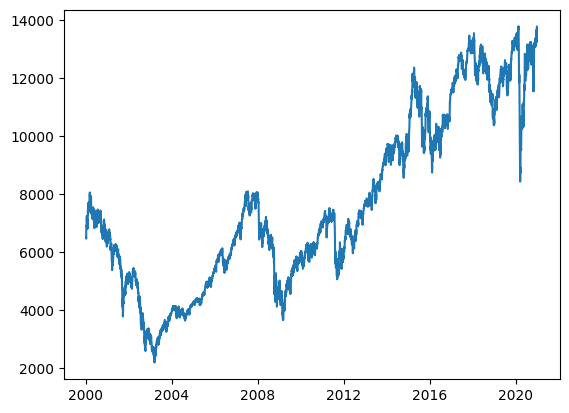

In [88]:
plt.plot(DAX['Date'], DAX['Close'])

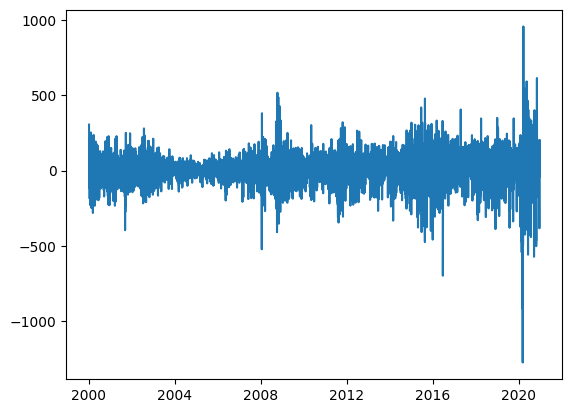

In [104]:
plt.plot(DAX['Date'], DAX['abs_return'])

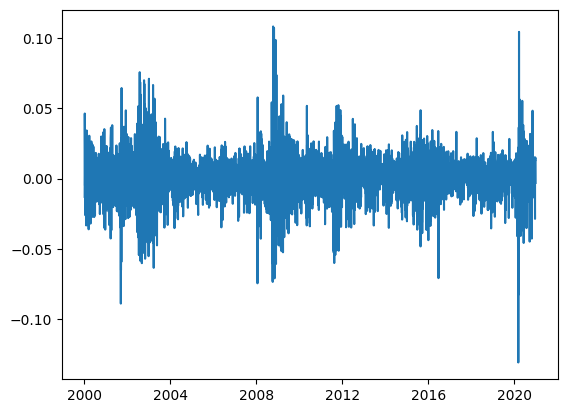

In [90]:
plt.plot(DAX['Date'], DAX['log_return'])

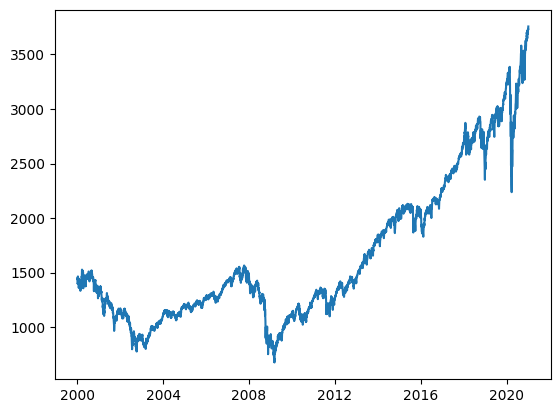

In [91]:
plt.plot(SP500['Date'], SP500['Close'])

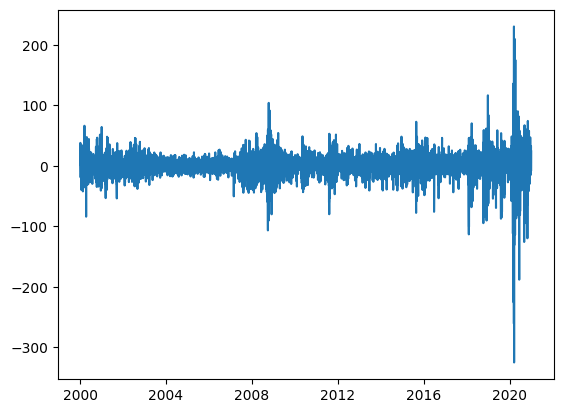

In [92]:
plt.plot(SP500['Date'], SP500['abs_return'])

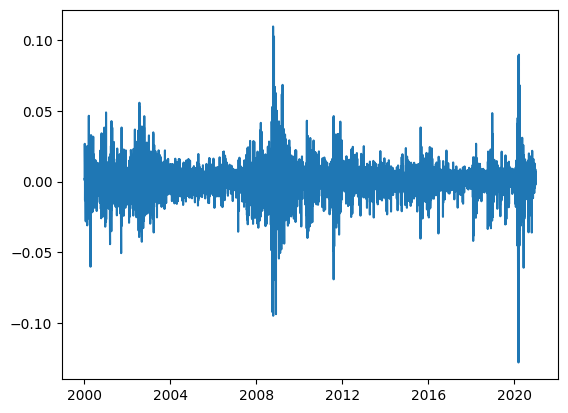

In [93]:
plt.plot(SP500['Date'], SP500['log_return'])

stationary: log returns  
non_stationary: close

returns are non stationary because the higher index value over time => higher volatility in absolute terms over time. It is not so easily visible though.

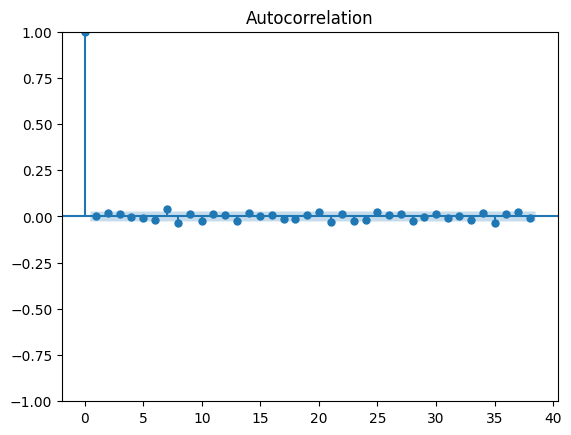

In [105]:
plot_acf(DAX['abs_return']);

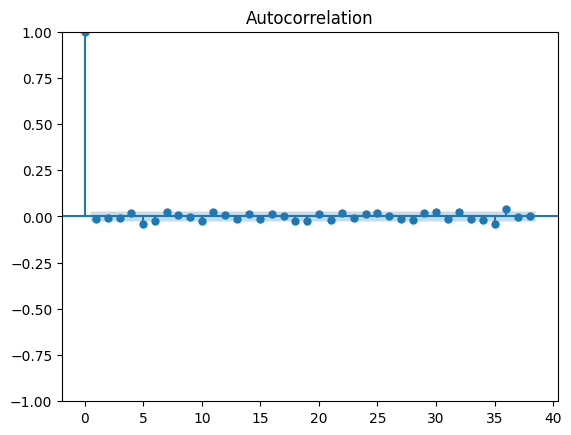

In [99]:
plot_acf(DAX['log_return']);

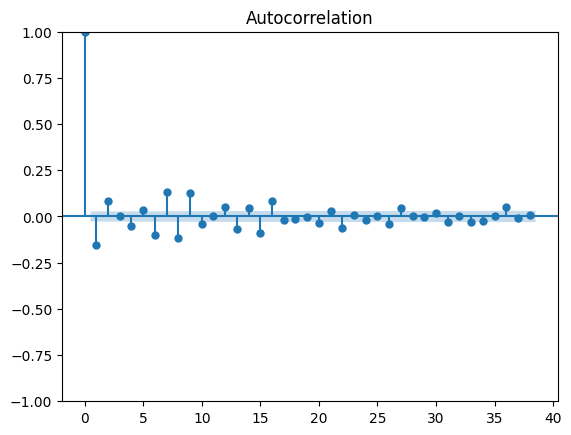

In [100]:
plot_acf(SP500['abs_return']);

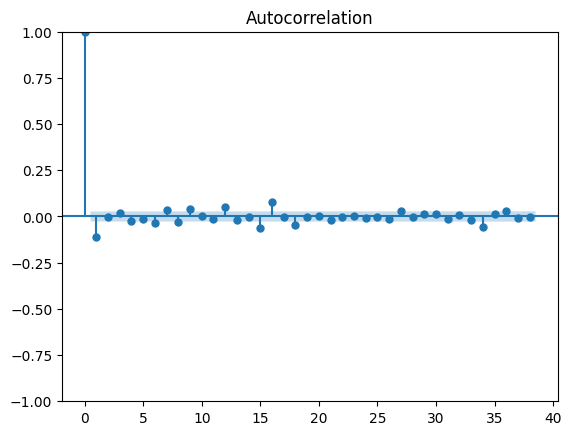

In [95]:
plot_acf(SP500['log_return']);

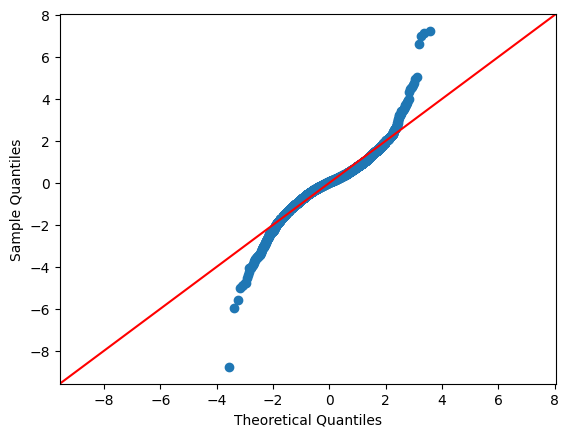

In [110]:
sm.qqplot(DAX['log_return'], line ='45', fit=True);

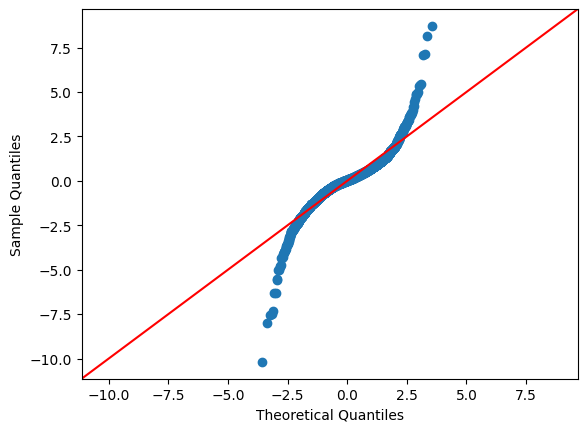

In [111]:
sm.qqplot(SP500['log_return'], line ='45', fit=True);

We find the following stylized facts:  
Log returns are not iid.  
Serial correlation in SP500 abs returns is significant, but goes in both directions. DAX doesn't seem to have any serial correlation in abs returns.  
Log returns seem to be serially uncorrelated.  
Volatility clusters.  
Log returns do NOT follow a normal distributions because they are heavy tailed.

In [115]:
summary = {'DAX': {'mean': DAX['log_return'].mean(), 'sd': DAX['log_return'].std()}, 'SP500': {'mean': SP500['log_return'].mean(), 'sd': SP500['log_return'].std()}}
print(summary)

{'DAX': {'mean': np.float64(0.00014097436063918305), 'sd': 0.014907396297535468}, 'SP500': {'mean': np.float64(0.00018644691421543808), 'sd': 0.012544312418126669}}


For finding a better fitting distribution, I refer to Marc Paolellas course: Statistical Methods for Finance

In [120]:
df = pd.merge(DAX, SP500, how='inner', on='Date', suffixes=('_DAX', '_SP500'))
df.head()

,Date,Open_DAX,High_DAX,Low_DAX,Close_DAX,abs_return_DAX,log_return_DAX,Open_SP500,High_SP500,Low_SP500,Close_SP500,abs_return_SP500,log_return_SP500
0,2000-01-07,6489.94,6780.96,6780.96,6780.96,306.04,0.046182,1441.47,1441.47,1400.53,1441.47,38.02,0.026730
1,2000-01-10,6785.47,6925.52,6925.52,6925.52,144.56,0.021094,1457.60,1464.36,1441.47,1457.60,16.13,0.011128
2,2000-01-11,6926.04,6891.25,6891.25,6891.25,-34.27,-0.004961,1438.56,1458.85,1434.42,1438.56,-19.04,-0.013149
3,2000-01-12,6878.92,6912.81,6912.81,6912.81,21.56,0.003124,1432.25,1445.29,1427.32,1432.25,-6.31,-0.004396
4,2000-01-13,6913.13,6955.98,6955.98,6955.98,43.17,0.006226,1449.68,1454.60,1432.25,1449.68,17.43,0.012096


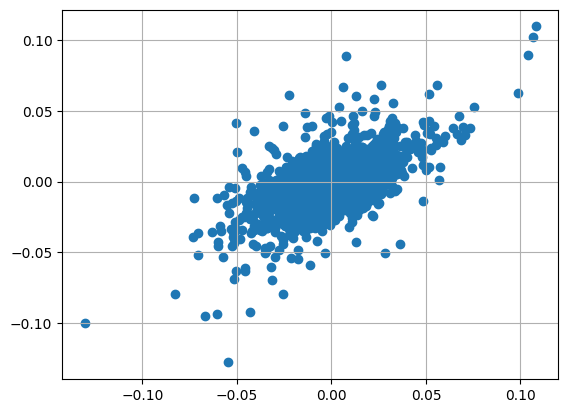

In [124]:
plt.scatter(df['log_return_DAX'], df['log_return_SP500'])
plt.grid(True)

The returns are correlated. Especially on the downside. At the center, it is a bit more independent-looking.